## Traffic Modeling
#### Starter Pack

In [3]:
import gzip
import struct
import pandas as pd

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt, pi, exp, erf, gamma, factorial

records = []

#Opens file "TR1.gz" given in assignment PDF
with gzip.open("TR1.gz", "rb") as f:
#with open(file_path, "rb") as f: #if it is autoDecompressed in your MACOS
    while True:
        data = f.read(20)
        if len(data) < 20:
            break

        #Interprets the web traffic that occurred once we took off the quotation marks   
        timestamp, client, obj, size, method, status, file_type, server = \
        struct.unpack(">IIIIBBBB", data)
        records.append([
        timestamp, client, obj, size,
        method, status, file_type, server
        ])

        #Probability and Statistical Modeling of Web Traffic 3

#Puts the interpreted traffic into a readable format
df = pd.DataFrame(records, columns=[
        "timestamp", "client_id", "object_id", "size",
        "method", "status", "type", "server"
        ])
df["datetime"] = pd.to_datetime(df["timestamp"], unit="s", utc=True)
df = df.sort_values("timestamp").reset_index(drop=True)


#Prints the web traffic that occurred
print(df.head())
print(df.shape)


#"Interarrival time between consecutive requests"
df["interarrival_time"] = df["timestamp"].diff()

#"Number of requests per minute"
df["minute"] = df["datetime"].dt.floor("min")
requests_per_minute = df.groupby("minute").size().reset_index(name="request_count")

#Preprocessing is complete above!





   timestamp  client_id  object_id  size  method  status  type  server  \
0  895615201      14275       6219   546       0      66     1      99   
1  895615201       3817        233   631       0      66     1      99   
2  895615201      28686        981  3717       0      66     1      99   
3  895615201     385403        403   993       0      66     1      99   
4  895615201     403925         56  2140       0     130     1      99   

                   datetime  
0 1998-05-19 22:00:01+00:00  
1 1998-05-19 22:00:01+00:00  
2 1998-05-19 22:00:01+00:00  
3 1998-05-19 22:00:01+00:00  
4 1998-05-19 22:00:01+00:00  
(3041727, 9)


In [4]:
df["interarrival_time"] = df["timestamp"].diff()

df["minute"] = df["datetime"].dt.floor("min")
requests_per_minute = df.groupby("minute").size().reset_index(name="request_count")

print(df.head())
print(df.shape)

T = df["interarrival_time"].dropna()


   timestamp  client_id  object_id  size  method  status  type  server  \
0  895615201      14275       6219   546       0      66     1      99   
1  895615201       3817        233   631       0      66     1      99   
2  895615201      28686        981  3717       0      66     1      99   
3  895615201     385403        403   993       0      66     1      99   
4  895615201     403925         56  2140       0     130     1      99   

                   datetime  interarrival_time                    minute  
0 1998-05-19 22:00:01+00:00                NaN 1998-05-19 22:00:00+00:00  
1 1998-05-19 22:00:01+00:00                0.0 1998-05-19 22:00:00+00:00  
2 1998-05-19 22:00:01+00:00                0.0 1998-05-19 22:00:00+00:00  
3 1998-05-19 22:00:01+00:00                0.0 1998-05-19 22:00:00+00:00  
4 1998-05-19 22:00:01+00:00                0.0 1998-05-19 22:00:00+00:00  
(3041727, 11)


### Part 1 - Probability from Observed Events

Matthew will be working in this cell, please create a different cell below

### Part 3 - Continuous Random Variables and Distributions

Approximate Mean: 0.02840393907932536
Approximate Variance: 0.027597155324103333
Standard Deviation: 0.16612391556938252
Median: 0.0
25th percentile: 0.0
75th percentile: 0.0
90th percentile: 0.0


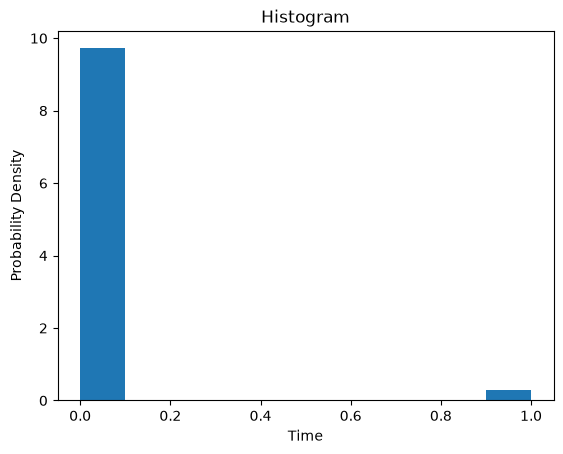

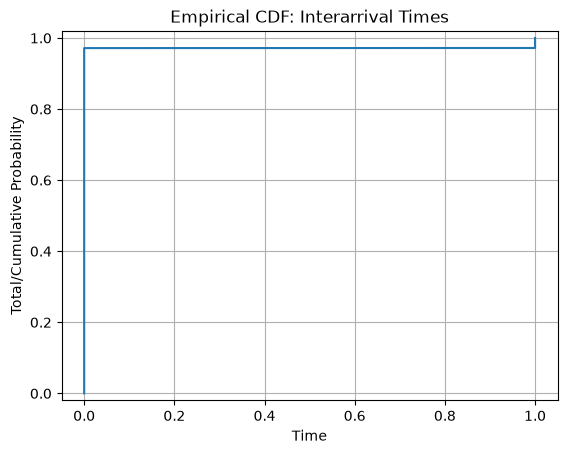

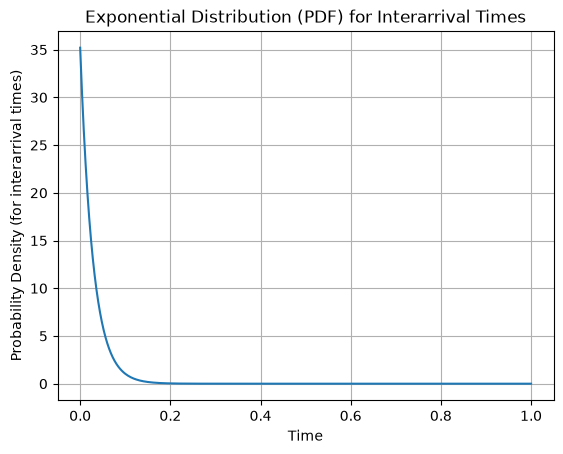

Mean: 0.02840393907932536
Variance: 0.0008067837552220261


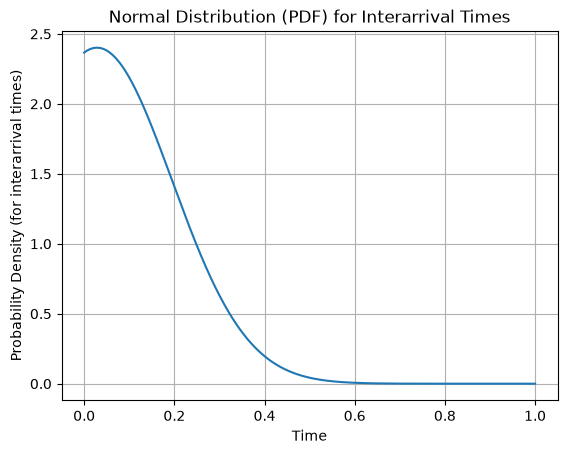

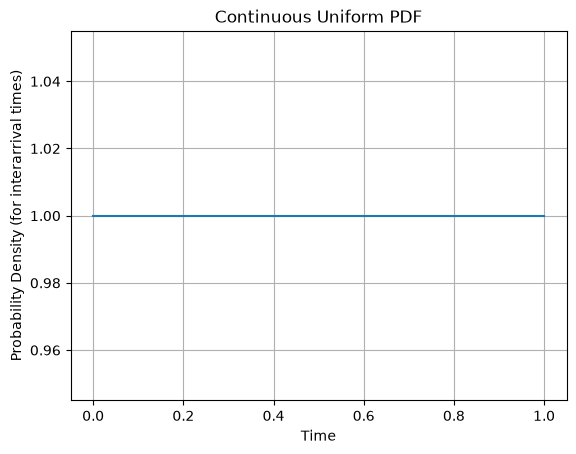

Combining:
Histogram
Exponential
Normal
Continuous Uniform


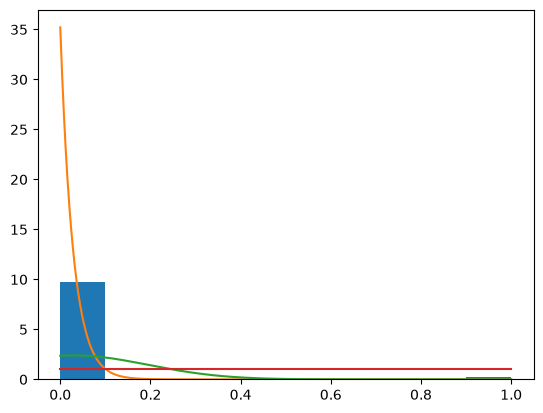

Estimated parameters are:
Exponential: 35.206384480942624
Normal: 0.02840393907932536 and 0.16612391556938252
Continuous Uniform: 0.0 and 1.0

The Exponential Distribution describes interarrival time most reasonably. The shape matches the histogram most closely with basically 
no observations at the far end on the right. The majority of observations on both of 
them are on the left near 0. Real web traffic may differ from idealized textbook models because real web traffic is not consistent unlike the textbook
would have you think. For example, instances of bursty traffic may occur suddenly because of, say, a large increase in interest from a recent popular 
advertisement. Similarly, DDOS attacks from hackers or bad actors trying to break the website or shut it down can be random and unpredictable, unlike 
ntextbook models. Textbook models don't account for the large variety of reasons web traffic can change!

P(T>t0)
Theoretical probability: 3.4083651739985424e-12
Empirical probability

In [ ]:

#Question 13

# Numerical approximation of mean and variance for interarrival time between consecutive requests 
# using Numpy


mean_approx = np.mean(T)
second_moment_approx = np.mean(T**2)
variance_approx = second_moment_approx - mean_approx**2
standard_deviation = np.sqrt(variance_approx)
median = np.median(T)
percentile_25 = np.percentile(T, 25)
percentile_75 = np.percentile(T, 75)
percentile_90 = np.percentile(T, 90)


print("Approximate Mean:", mean_approx)
print("Approximate Variance:", variance_approx)
print("Standard Deviation:", standard_deviation)
print("Median:", median)
print("25th percentile:", percentile_25)
print("75th percentile:", percentile_75)
print("90th percentile:", percentile_90)


#Plot the histogram, code from Statistical Practice 4
#Q15: Changes histogram to probability density to be able to compare to other graphs
plt.hist(T,bins = 10, density = True)
plt.xlabel("Time")
plt.ylabel("Probability Density")
plt.title("Histogram")
plt.show()



#Empirical CDF, from Statistical Practice 4
def plot_cdf(x, y, title):
    plt.figure()
    plt.plot(x, y)
    plt.xlabel("Time")
    plt.ylabel("Total/Cumulative Probability")
    plt.title(title)
    plt.ylim(-0.02, 1.02)
    plt.grid(True)
    plt.show()

x = np.sort(T)

y = np.arange(1, len(x) + 1) / len(x)


plot_cdf(x, y, "Empirical CDF: Interarrival Times")


#Exponential Distribution, from Statistical Practice 4
# Exponential example
# A security monitoring system generates intrusion alerts at an average rate of 3 per hour.
# X = waiting time until the next alert, in hours.

def plot_pdf(x, y, title):
    plt.figure()
    plt.plot(x, y)
    plt.xlabel("Time")
    plt.ylabel("Probability Density (for interarrival times)")
    plt.title(title)
    plt.grid(True)
    plt.show()


lam = 1/mean_approx

x = np.linspace(0, 1, 500)
expon_pdf = lam * np.exp(-lam * x)

plot_pdf(x, expon_pdf, "Exponential Distribution (PDF) for Interarrival Times")

print("Mean:", 1 / lam)
print("Variance:", 1 / lam**2)


#Normal Distribution, from Statistical Practice 4

def normal_pdf(x, mu=0, sigma=1):
    return (1 / (sigma * sqrt(2 * pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

mu = mean_approx
sigma = standard_deviation

x = np.linspace(0, 1, 500)
norm_pdf = normal_pdf(x, mu, sigma)

plot_pdf(x, norm_pdf, "Normal Distribution (PDF) for Interarrival Times")


#Continuous Uniform Distribution, from Statistics Practice 4 and Numpy for parameters

a = np.min(T)
b = np.max(T)

x = np.linspace(0, 1, 500)
cont_pdf = np.where((x >= a) & (x <= b), 1/(b-a), 0)


plot_pdf(x, cont_pdf, "Continuous Uniform PDF")



#Overlay of all graphs
print("Combining:\nHistogram")
plt.hist(T,bins = 10, density = True)
print("Exponential")
plt.plot(x, expon_pdf)
print("Normal")
plt.plot(x,norm_pdf)
print("Continuous Uniform")
plt.plot(x,cont_pdf)
plt.show()
print("Estimated parameters are:")
print("Exponential:", lam)
print("Normal:", mu,"and", sigma)
print("Continuous Uniform:", a,"and",b)



#Q16
print("\nThe Exponential Distribution describes interarrival time most reasonably. The shape matches the histogram most closely with basically \nno observations at the far end on the right. The majority of observations on both of \nthem are on the left near 0. Real web traffic may differ from idealized textbook models because real web traffic is not consistent unlike the textbook\nwould have you think. For example, instances of bursty traffic may occur suddenly because of, say, a large increase in interest from a recent popular \nadvertisement. Similarly, DDOS attacks from hackers or bad actors trying to break the website or shut it down can be random and unpredictable, unlike \ntextbook models. Textbook models don't account for the large variety of reasons web traffic can change!")


#Q17
t0 = 0.75
#Adapted from Statistical Practice 4 code
theoretical_probability_one = np.exp(-lam * t0)
empirical_probability = np.mean(T > t0)
print("\nP(T>t0)")
print("Theoretical probability:", theoretical_probability_one)
print("Empirical probability:", empirical_probability)

t1 = 0.3
t2 = 0.9
theoretical_two = np.exp(-lam * t1) - np.exp(-lam * t2)
empirical_two = np.mean((T>t1) & (T<t2))
print("\nP(t1< T <t2)")
print("Theoretical:", theoretical_two)
print("Empirical:", empirical_two)


#Q18
print("\nA lognormal model would be reasonable to use because lognormal specifically have values above zero and display a distribution that is right skewed. \nThe data shown on the histogram is clearly skewed to the right with a long tail, with an even clearer showcase in the exponential model. ")


#Q19
print("\nUniform is not reasonable because the histogram is concentrated overwhelmingly at or around 0, with some observations at or near 1. \nUniform distributions should be used with data that has consistent probabilities across its x-axis (in this case time), and this histogram clearly does not have that.")

